In [1]:
import sys
import pandas as pd
import glob
import numpy as np
import os
import pickle
import scipy as scp
import seaborn as sns 
import matplotlib.pyplot as plt
sys.path.append(r"D:\github\dynamic_model_of_cocktail_party_nightmare\dynamic_model")

from scores.collision_scores import compute_collision_counts_and_length
from scores.run_all_score_calculations import filter_bat_positions_from_history
from supporting_files.utilities import load_history_dump, load_parameters


# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.size'] = 12
# plt.rcParams['axes.labelsize'] = 12
# plt.rcParams['axes.titlesize'] = 12
# plt.rcParams['xtick.labelsize'] = 12
# plt.rcParams['ytick.labelsize'] = 12
# plt.rcParams['legend.fontsize'] = 12
# plt.rcParams['figure.titlesize'] = 12

In [2]:
# group_sizes

with open(r"D:\github\dynamic_model_of_cocktail_party_nightmare\group_size_100_condensed_data_whole.pickle", "rb") as f:
    store_scores = pickle.load(f)


In [3]:
raw_df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
raw_df= raw_df[raw_df["duration"]==30]
raw_df = raw_df[raw_df["consistency_type"]=="3/5"]

In [4]:
big_output_dir = "/media/adityamoger/T7 Shield/BACKUP_THESIS_DATA"
treatment_dir = big_output_dir + "/*_treatment"
null_dir = big_output_dir + "/*_null"
consistency_types = ["3/5", "2/3"]
experiment_types = ["positive_control", "negative_control", "treatment", "null"]
group_sizes = [5, 10, 30, 50, 75, 100]
iterations = np.arange(0, 20, 1)

store_individual_scores_labels = [
    (
        "experiment_type",
        "group_size",
        "iteration",
        "collision_counts",
        "wall_collision_counts",
        "bat_bat_collision_counts",
        "duration",
        "consistency_type",
        "bat_id",
    )
]



In [5]:
df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
df= df[df["duration"]==30]
df= df[df["consistency_type"]=="3/5"]
df

,experiment_type,group_size,iteration,collision_counts,wall_collision_counts,bat_bat_collision_counts,duration,consistency_type
0,positive_control,5,0,59,34,25,30.0,3/5
2,positive_control,5,1,55,28,27,30.0,3/5
4,positive_control,5,2,68,36,32,30.0,3/5
6,positive_control,5,3,58,27,31,30.0,3/5
8,positive_control,5,4,56,27,29,30.0,3/5
...,...,...,...,...,...,...,...,...
950,null,100,15,2191,815,1376,30.0,3/5
952,null,100,16,2137,807,1330,30.0,3/5
954,null,100,17,2133,813,1320,30.0,3/5
956,null,100,18,2156,798,1358,30.0,3/5


<Axes: xlabel='duration', ylabel='Count'>

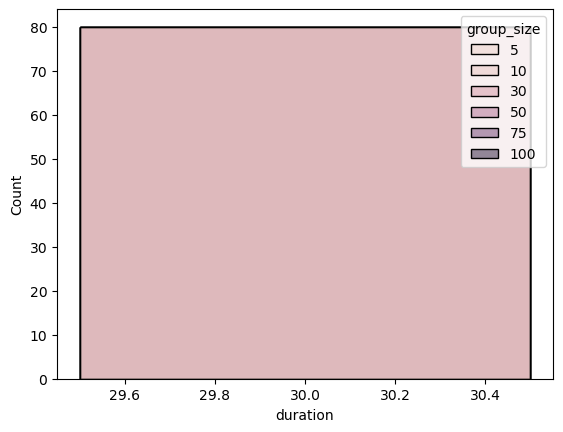

In [6]:
sns.histplot(df, x="duration",hue="group_size")

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
# plt.style.use('ggplot')

In [8]:
df.keys()

Index(['experiment_type', 'group_size', 'iteration', 'collision_counts',
       'wall_collision_counts', 'bat_bat_collision_counts', 'duration',
       'consistency_type'],
      dtype='object')

<Axes: xlabel='group_size', ylabel='collision_counts'>

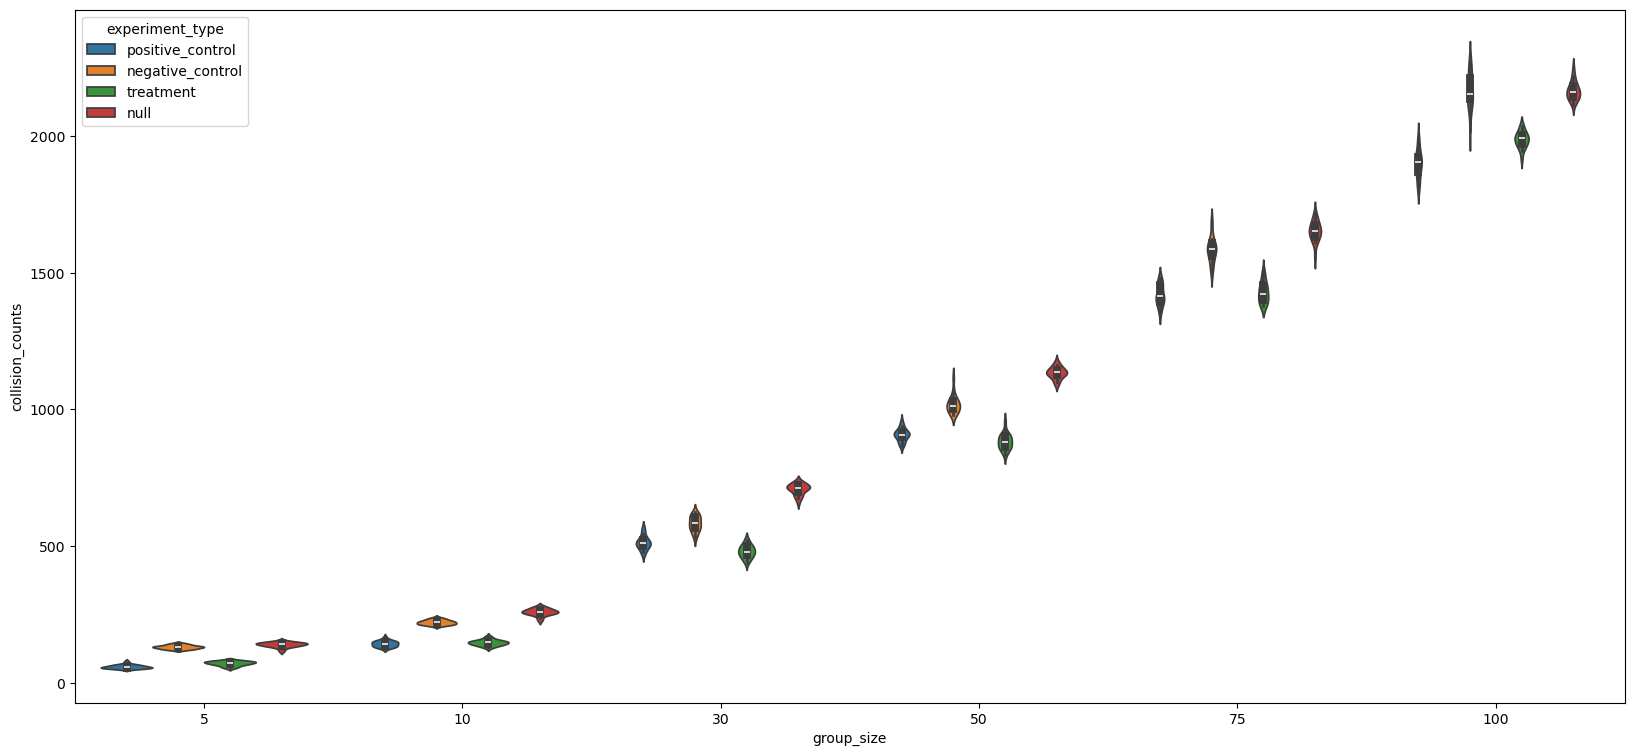

In [9]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.violinplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts", hue="experiment_type")


<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

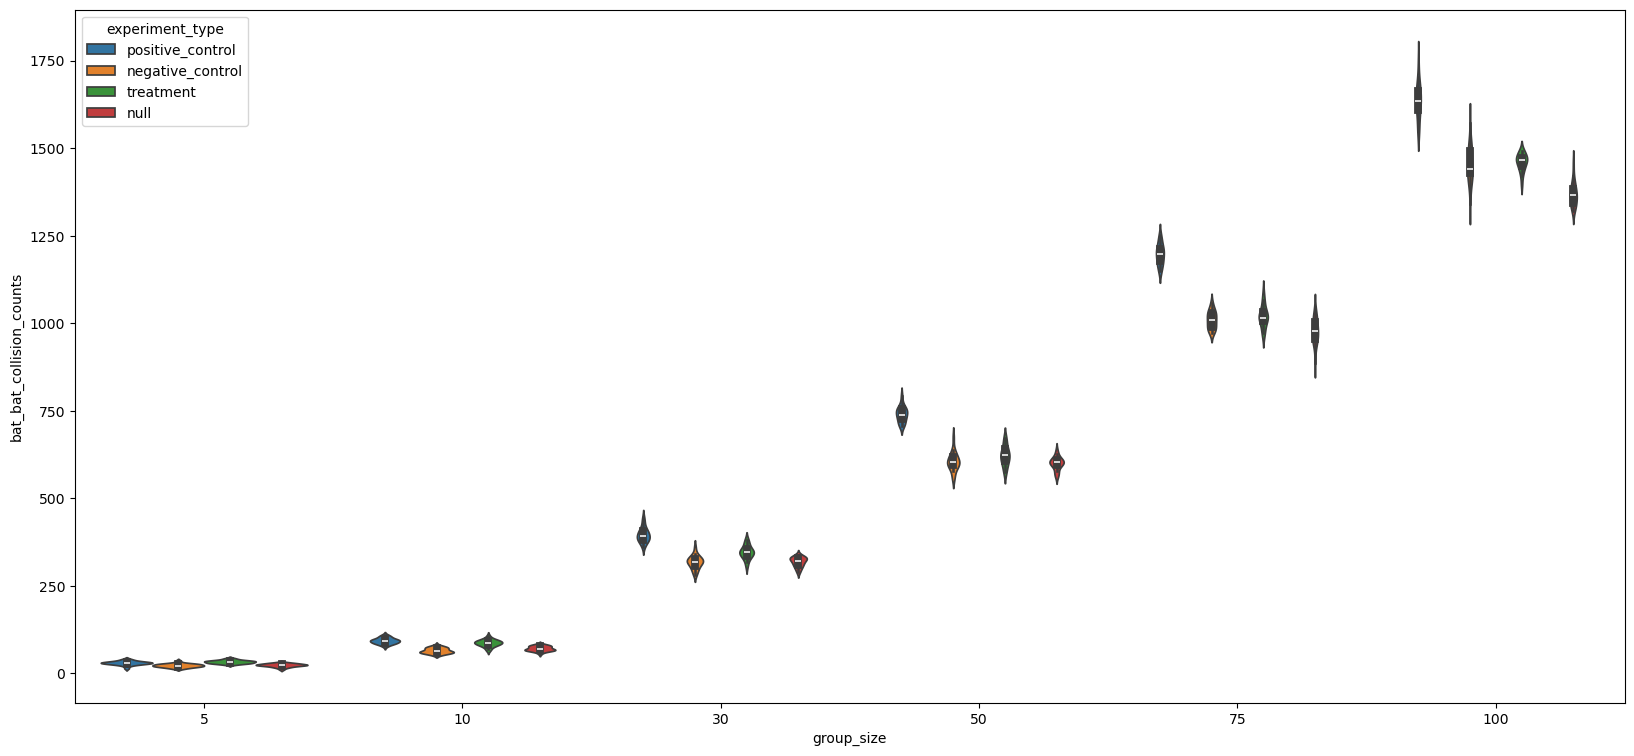

In [10]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.violinplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts", hue="experiment_type")


<Axes: xlabel='group_size', ylabel='wall_collision_counts'>

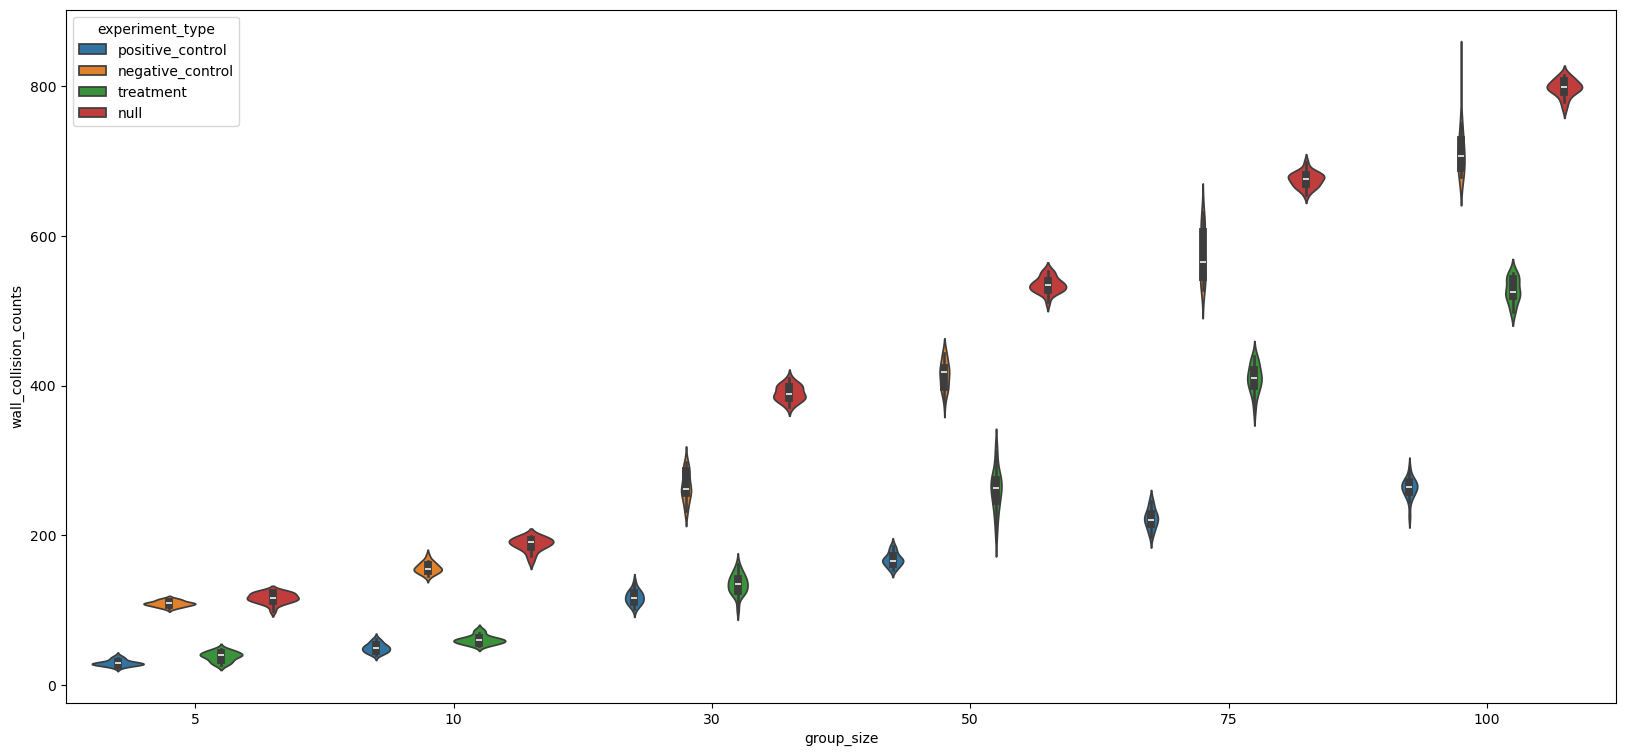

In [11]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.violinplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts", hue="experiment_type")



<Axes: ylabel='wall_collision_counts'>

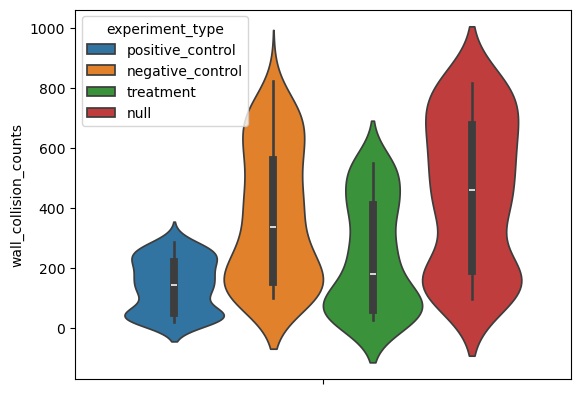

In [12]:
sns.violinplot(df, y="wall_collision_counts", hue="experiment_type")

<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

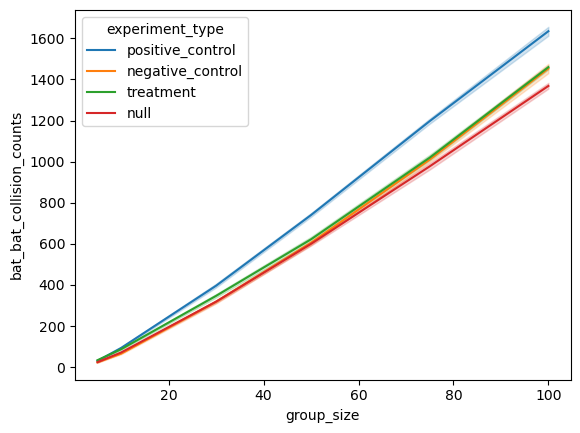

In [13]:
sns.lineplot(df, x="group_size", y="bat_bat_collision_counts", hue="experiment_type")

<Axes: xlabel='group_size', ylabel='collision_counts'>

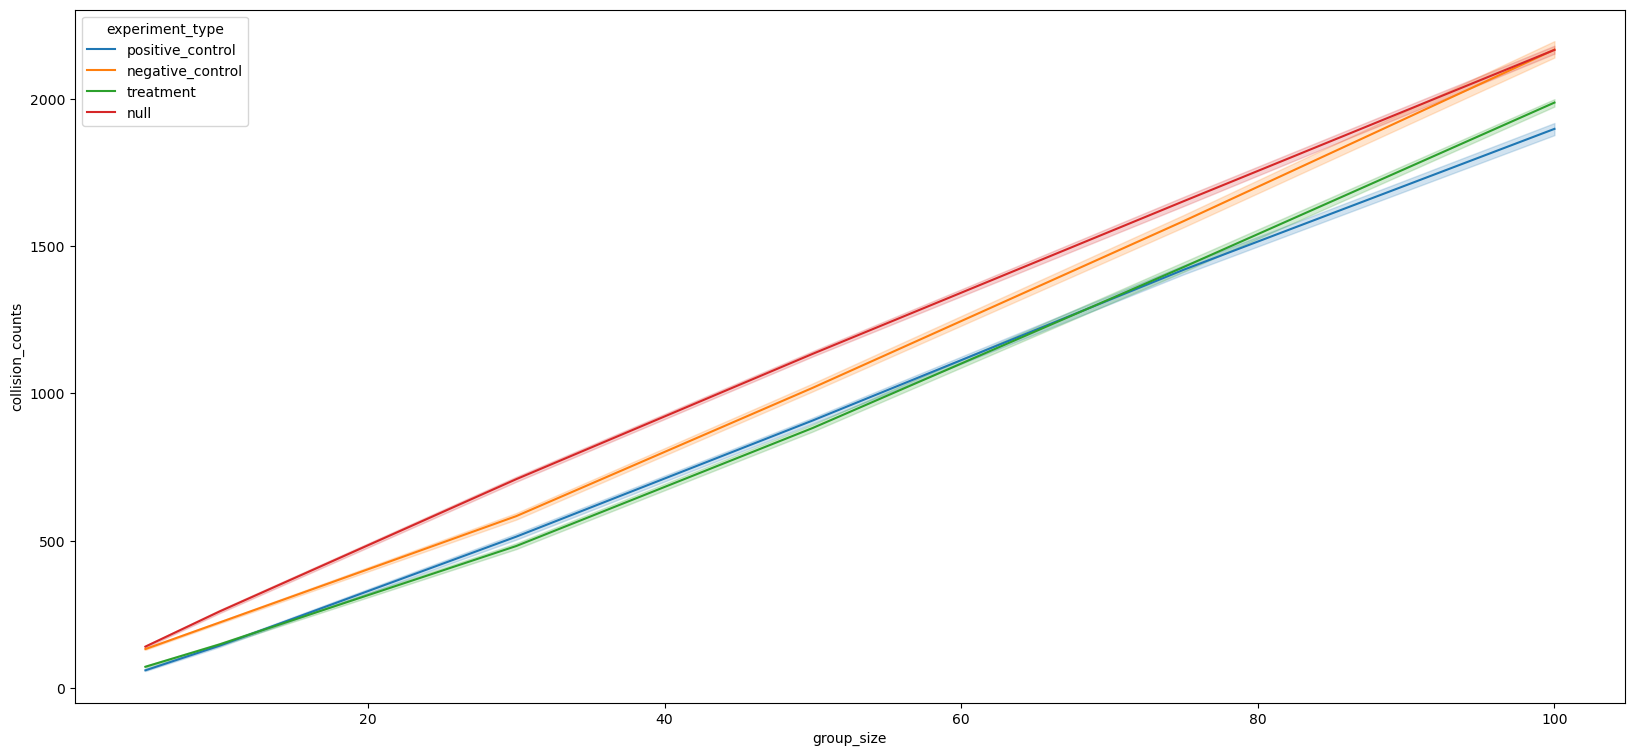

In [14]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts", hue="experiment_type")

# plt.ylim(0,40)

<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

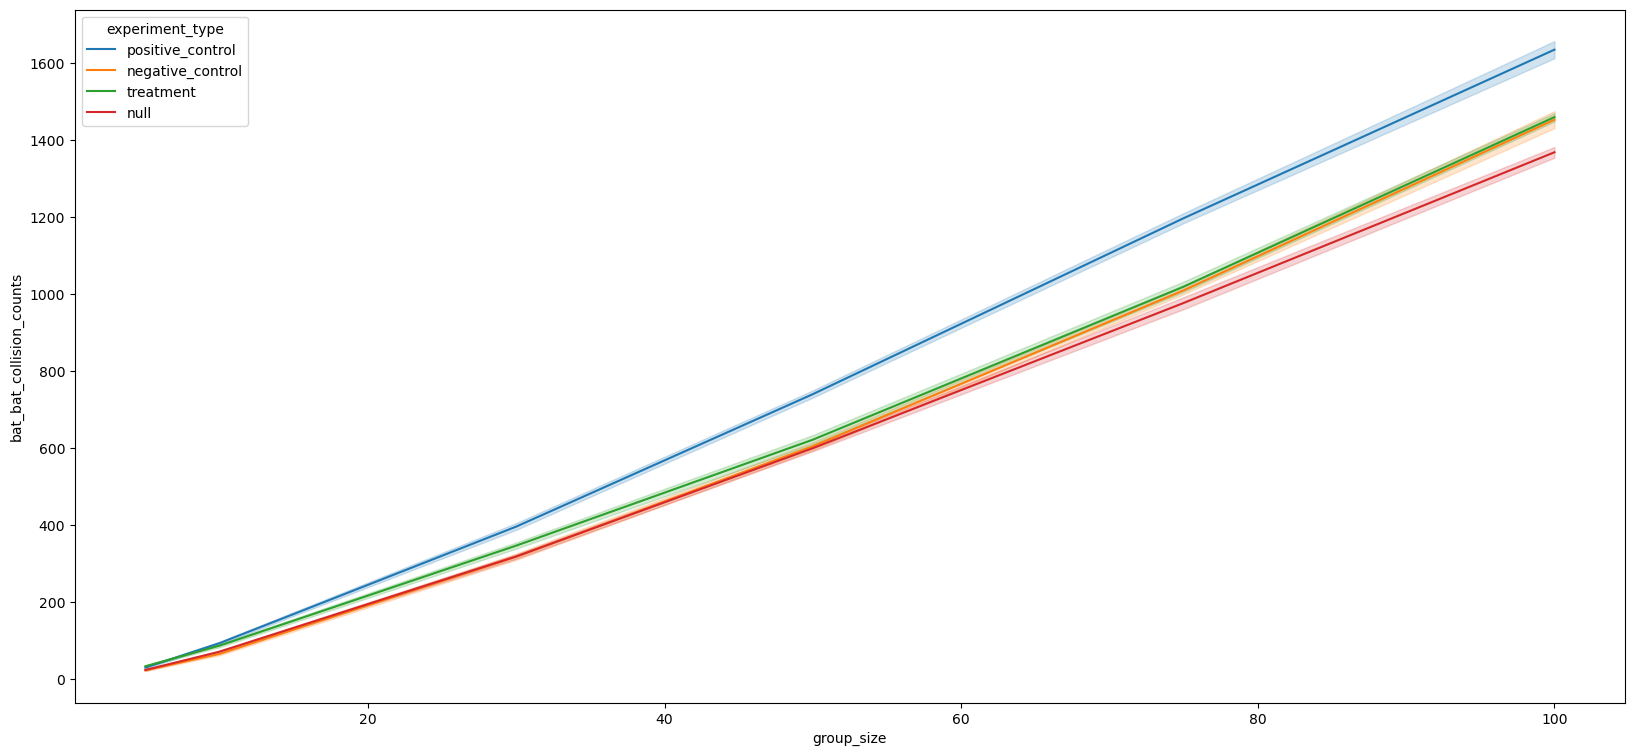

In [15]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts", hue="experiment_type")


<Axes: xlabel='group_size', ylabel='wall_collision_counts'>

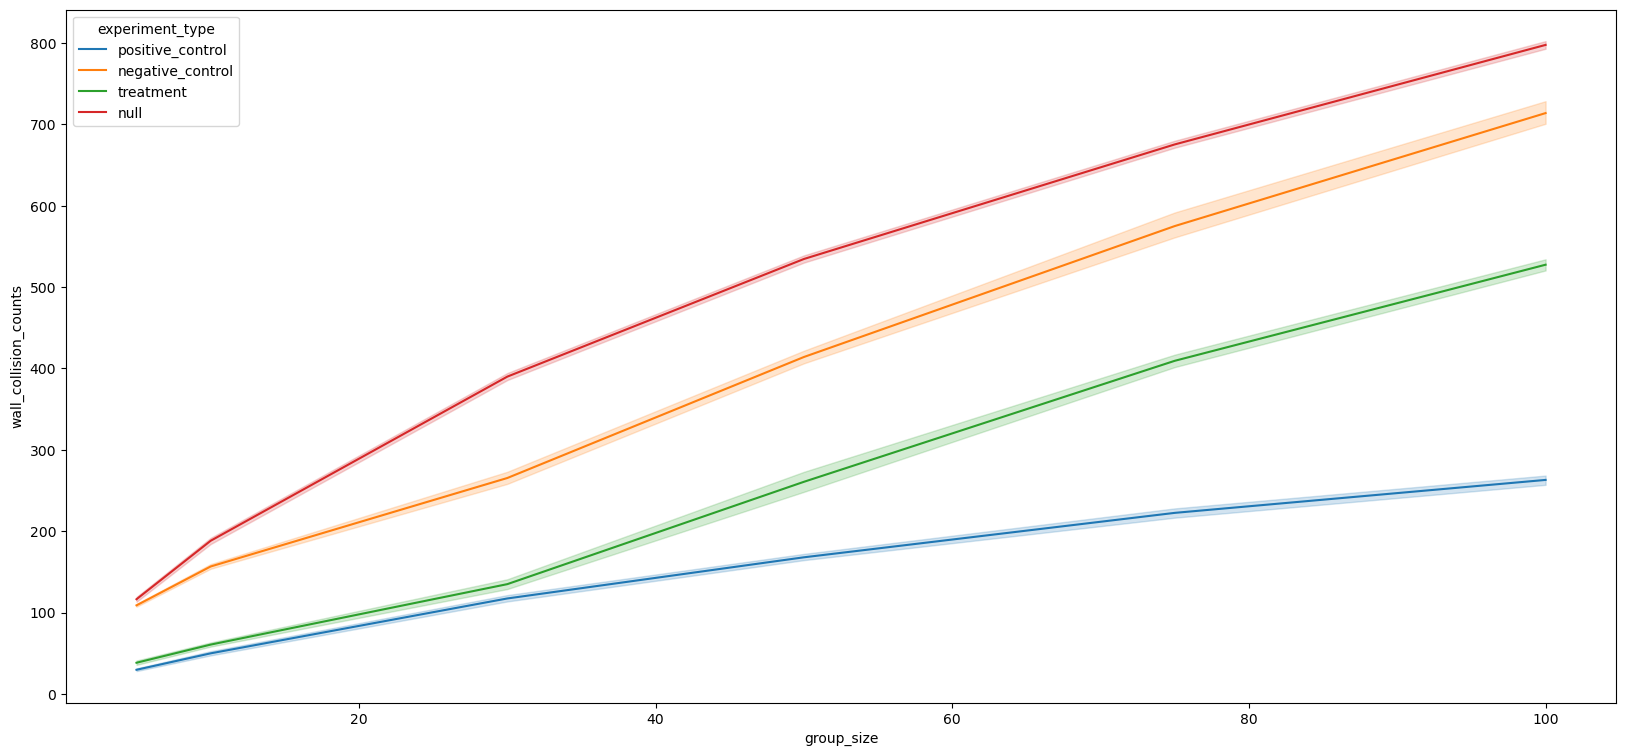

In [16]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts", hue="experiment_type")

In [17]:
df["collision_counts_scaled"] = df["collision_counts"]/(df["group_size"])
df["wall_collision_counts_scaled"] = df["wall_collision_counts"]/df["group_size"]
df["bat_bat_collision_counts_scaled"] = df["bat_bat_collision_counts"]/df["group_size"]

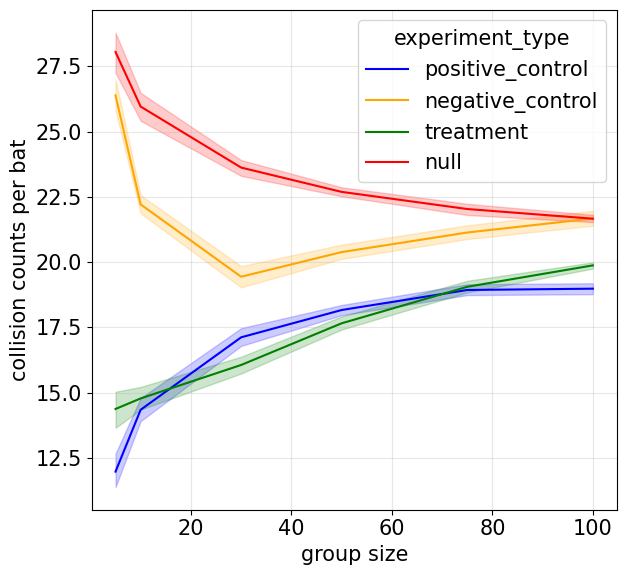

In [40]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts_scaled", hue="experiment_type", palette = ["b", "orange", "g", "r"])
plt.ylabel('collision counts per bat')
plt.xlabel('group size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.rcParams['font.size'] = 15
# plt.style.use('dark_background')
plt.savefig("collisioncountsvsgroupsize.svg", transparent= True)

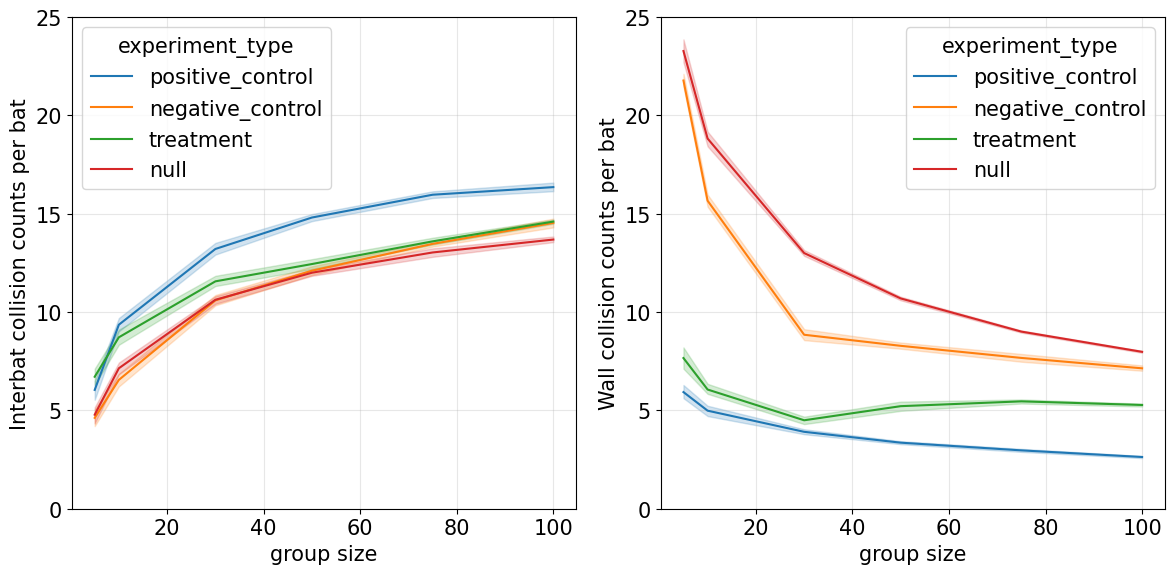

In [41]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type")
plt.ylim(0,25)
plt.ylabel('Interbat collision counts per bat')
plt.xlabel('group size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
plt.ylim(0,25)
plt.ylabel('Wall collision counts per bat')
plt.xlabel('group size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("collisioncountsvsgroupsize_breakdown.svg", transparent= True)

<Axes: xlabel='group_size', ylabel='wall_collision_scaled_time_and_size'>

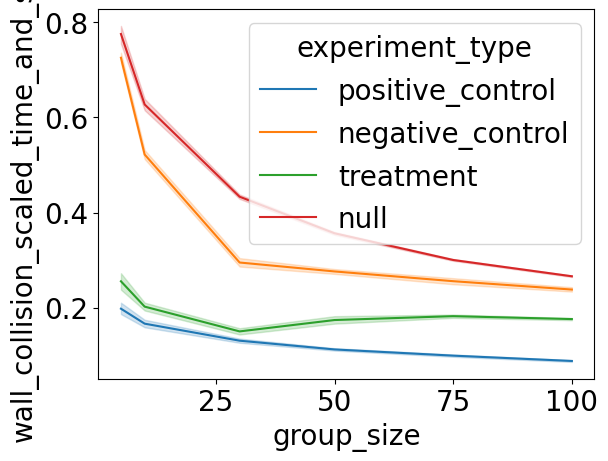

In [20]:
df["collision_scaled_time_and_size"] = df["collision_counts"]/(df["group_size"]*30)
df["wall_collision_scaled_time_and_size"] = df["wall_collision_counts"]/(df["group_size"]*30)
df["bat_bat_collision_scaled_time_and_size"] = df["bat_bat_collision_counts"]/(df["group_size"]*30)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_scaled_time_and_size", hue="experiment_type")

In [21]:
df_tr = df.loc[(df["experiment_type"]=="treatment")&(df["consistency_type"]=="3/5")].reset_index()
df_nu = df.loc[(df["experiment_type"]=="null")&(df["consistency_type"]=="3/5")].reset_index()
df_nc = df.loc[(df["experiment_type"]=="negative_control")&(df["consistency_type"]=="3/5")].reset_index()
df_pc = df.loc[(df["experiment_type"]=="positive_control")&(df["consistency_type"]=="3/5")].reset_index()
# plt.plot(df_tr["collision_counts"].values - df_pc["collision_counts"].values)
pc_group_by = df_pc.groupby("group_size")
tr_group_by = df_tr.groupby("group_size")
nc_group_by = df_nc.groupby("group_size")
nu_group_by = df_nu.groupby("group_size")
# 
df_model_performance = pd.DataFrame(columns=df_pc.keys())
for group_size in group_sizes:
    tr = tr_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    # print(tr["wall_collision_counts_scaled"])
    pc = pc_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    # print(pc["wall_collision_counts_scaled"])
    nc = nc_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    nu = nu_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    
    model_performance = ((tr-pc)/nu)
    print(group_size, model_performance["collision_counts"])
    # df_model_performance = pd.concat((df_model_performance, ))
# df_model_performance
# pd.DataFrame(model_performance, columns=list(df_pc.keys().values)[2:])
# print(list(df_pc.keys())[2:])


5 0.08556149732620316
10 0.01675654853620953
30 -0.044874056304240476
50 -0.022432789775231318
75 0.00553706505295013
100 0.041224263687563455


In [22]:
import numpy as np
from scipy import stats
for group_size in group_sizes:
    tr_subset = tr_group_by.get_group(group_size)
    pc_subset = pc_group_by.get_group(group_size)
    ttstats = stats.ttest_ind(tr_subset["collision_counts"], pc_subset["collision_counts"])
    print(ttstats)

TtestResult(statistic=5.0483203774627485, pvalue=1.1415360043730976e-05, df=38.0)
TtestResult(statistic=1.315268898577423, pvalue=0.196301087924614, df=38.0)
TtestResult(statistic=-4.202786980221328, pvalue=0.00015401557068508656, df=38.0)
TtestResult(statistic=-3.1215741651402857, pvalue=0.0034303951750663513, df=38.0)
TtestResult(statistic=0.7683484087047984, pvalue=0.4470291474092868, df=38.0)
TtestResult(statistic=6.792272701178501, pvalue=4.7038619655427004e-08, df=38.0)


<Axes: xlabel='group_size', ylabel='wall_collision_counts_scaled'>

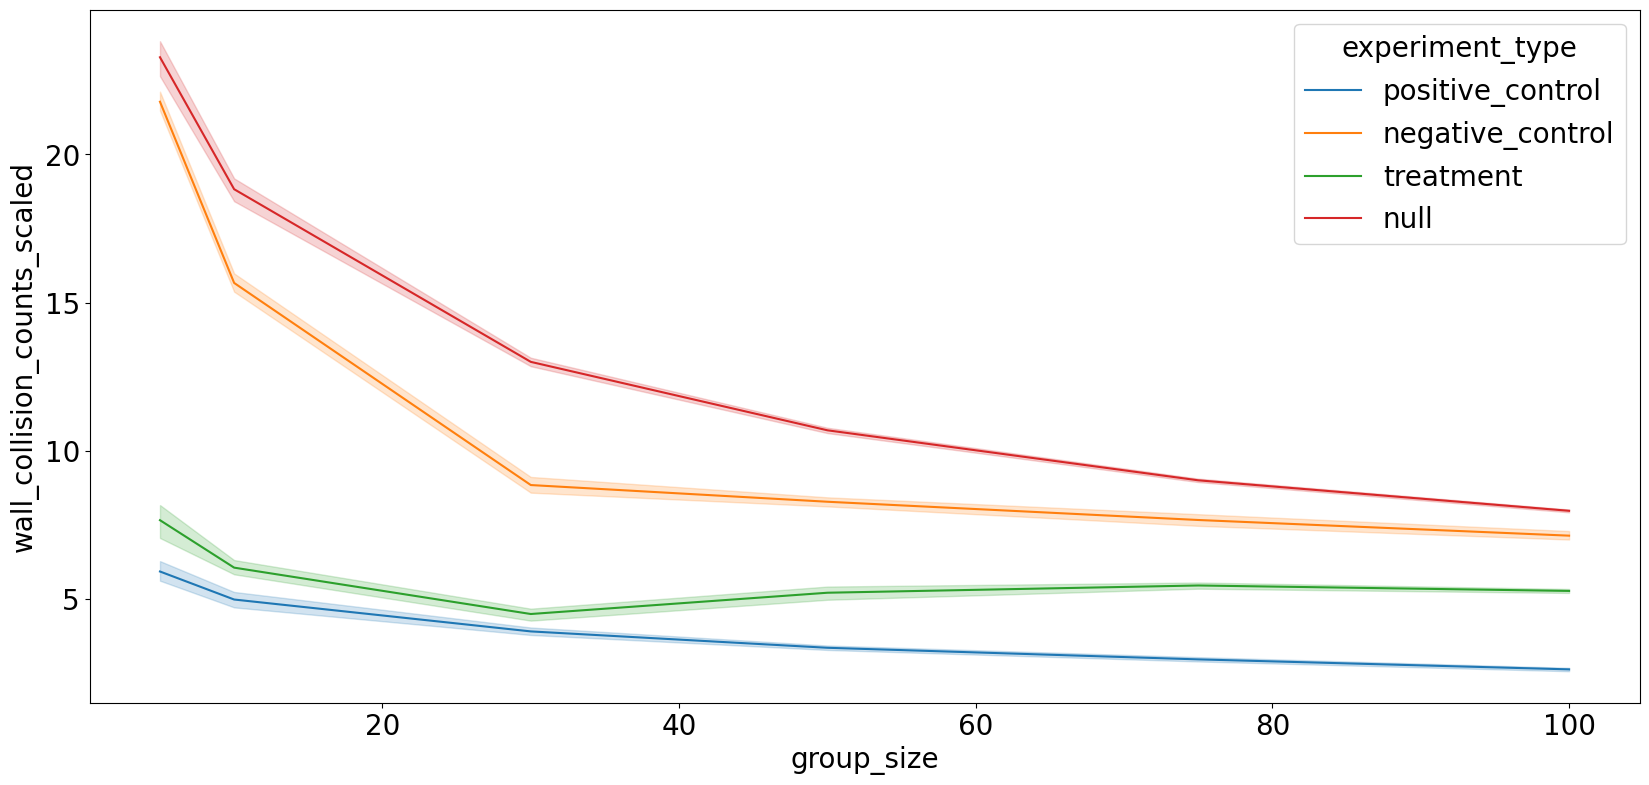

In [23]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
# plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type", ls="-.")

In [24]:
df

,experiment_type,group_size,iteration,collision_counts,wall_collision_counts,bat_bat_collision_counts,duration,consistency_type,collision_counts_scaled,wall_collision_counts_scaled,bat_bat_collision_counts_scaled,collision_scaled_time_and_size,wall_collision_scaled_time_and_size,bat_bat_collision_scaled_time_and_size
0,positive_control,5,0,59,34,25,30.0,3/5,11.80,6.80,5.00,0.393333,0.226667,0.166667
2,positive_control,5,1,55,28,27,30.0,3/5,11.00,5.60,5.40,0.366667,0.186667,0.180000
4,positive_control,5,2,68,36,32,30.0,3/5,13.60,7.20,6.40,0.453333,0.240000,0.213333
6,positive_control,5,3,58,27,31,30.0,3/5,11.60,5.40,6.20,0.386667,0.180000,0.206667
8,positive_control,5,4,56,27,29,30.0,3/5,11.20,5.40,5.80,0.373333,0.180000,0.193333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,null,100,15,2191,815,1376,30.0,3/5,21.91,8.15,13.76,0.730333,0.271667,0.458667
952,null,100,16,2137,807,1330,30.0,3/5,21.37,8.07,13.30,0.712333,0.269000,0.443333
954,null,100,17,2133,813,1320,30.0,3/5,21.33,8.13,13.20,0.711000,0.271000,0.440000
956,null,100,18,2156,798,1358,30.0,3/5,21.56,7.98,13.58,0.718667,0.266000,0.452667


In [45]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.genmod.families import NegativeBinomial
import pandas as pd
from patsy.contrasts import Treatment
# Convert all predictors to categorical (one-hot encoding)
# predictors = varying_params
varying_params = ["experiment_type", 'group_size']
labels = ['experiment type', 'group size']
df_cat = df.copy()

df_cat["group_size"] = pd.Categorical(df_cat["group_size"])
df_cat["experiment_type"] = pd.Categorical(df_cat["experiment_type"])

formula = """
collision_counts ~ C(experiment_type, Treatment(reference="positive_control")) + C(group_size, Treatment(reference=50))
"""

# First fit Poisson to estimate dispersion
poisson_model = smf.glm(formula=formula, data=df_cat, family=sm.families.Poisson()).fit()
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
print(dispersion)
alpha = 1/dispersion

# Fit Negative Binomial with categorical variables
model_nb = smf.glm(
    formula=formula,
    data=df_cat,
    family=NegativeBinomial(alpha=alpha),
    # contrasts=contrast_code
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)")
print(model_nb.summary2())
print(f"\nFinal alpha parameter: {model_nb.family.alpha:.4f}")

4.220940109196389
NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)
                                               Results: Generalized linear model
Model:                                     GLM                                   AIC:                                 6338.8009 
Link Function:                             Log                                   BIC:                                 -2875.7887
Dependent Variable:                        collision_counts                      Log-Likelihood:                      -3160.4   
Date:                                      2026-05-13 17:54                      LL-Null:                             -4112.3   
No. Observations:                          480                                   Deviance:                            32.065    
Df Model:                                  8                                     Pearson chi2:                        30.8      
Df Residuals:                              471                    

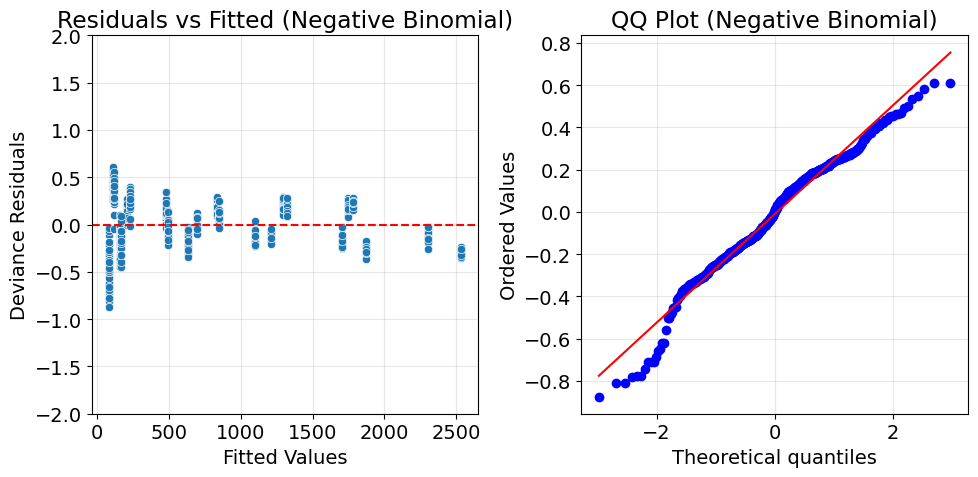

In [46]:
plt.rcParams['font.size'] = 14
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.scatterplot(x=model_nb.fittedvalues, y=model_nb.resid_deviance)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Negative Binomial)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-2,2)
# plt.tight_layout()
# plt.show()

# QQ Plot

plt.subplot(1,2,2)
stats.probplot(model_nb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Negative Binomial)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("collisioncountsvsgroupsize_glm_resid.svg", transparent= True)

In [43]:
results = model_nb.summary2().tables[1]
categorical_params = [p for p in results.index if '[' in p]
print(categorical_params)
# Create a plot for each parameter
baseline_df = pd.DataFrame()
baseline_df["parameter"] = varying_params
baseline_df["odds_ratio"] = [1] * len(varying_params)
baseline_df["parameter_value"] = ['positive control', 50]
baseline_df["ci_low"] = [1] * len(varying_params)
baseline_df["ci_high"] = [1] * len(varying_params)
baseline_df["pvalue"] = [0] * len(varying_params)
baseline_df["coeffs"] = [0] * len(varying_params)

parameter_list = []
parameter_value_list = []
odds_ratio_list = []
ci_low_list = []
ci_high_list = []
pvalue_list = []
coeffs_list = []

for param in categorical_params:
    # Extract base parameter name and category
    base_param = param.split(',')[0].split(")")[0][2:]
    # base_param = param.split('[')[0]
    category = param.split('[')[1].split(']')[0].replace('T.', '')
    if category not in ["negative_control", "null", "treatment"]:
        category = float(category)
    # print(category)
    
    or_val = np.exp(results.loc[param, 'Coef.'])
    ci_low = np.exp(results.loc[param, '[0.025'])
    ci_high = np.exp(results.loc[param, '0.975]'])
    pvalue = results.loc[param, 'P>|z|']
    coeff= results.loc[param, 'Coef.']
    
    parameter_value_list.append(category)
    parameter_list.append(base_param)
    odds_ratio_list.append(or_val)
    ci_low_list.append(ci_low)
    ci_high_list.append(ci_high)
    pvalue_list.append(pvalue)
    coeffs_list.append(coeff)
    
new_df = pd.DataFrame()
new_df["parameter"] = parameter_list
new_df["odds_ratio"] = odds_ratio_list
new_df["parameter_value"] = parameter_value_list
new_df["ci_low"] = ci_low_list
new_df["ci_high"] = ci_high_list
new_df["pvalue"] = pvalue_list
new_df["coeffs"] = coeffs_list
condensed_nb_df = pd.concat((baseline_df,new_df)).reset_index()
condensed_nb_df.sort_values('parameter').to_csv("group_nb_irr.csv")
condensed_nb_df

['C(experiment_type, Treatment(reference="positive_control"))[T.negative_control]', 'C(experiment_type, Treatment(reference="positive_control"))[T.null]', 'C(experiment_type, Treatment(reference="positive_control"))[T.treatment]', 'C(group_size, Treatment(reference=50))[T.5]', 'C(group_size, Treatment(reference=50))[T.10]', 'C(group_size, Treatment(reference=50))[T.30]', 'C(group_size, Treatment(reference=50))[T.75]', 'C(group_size, Treatment(reference=50))[T.100]']


,index,parameter,odds_ratio,parameter_value,ci_low,ci_high,pvalue,coeffs
0,0,experiment_type,1.000000,positive control,1.000000,1.000000,0.000000e+00,0.000000
1,1,group_size,1.000000,50,1.000000,1.000000,0.000000e+00,0.000000
2,0,experiment_type,1.318647,negative_control,1.164839,1.492765,1.235313e-05,0.276606
3,1,experiment_type,1.450268,null,1.281150,1.641711,4.193235e-09,0.371749
4,2,experiment_type,1.021636,treatment,0.902376,1.156658,7.353724e-01,0.021406
5,3,group_size,0.098398,5.0,0.084467,0.114626,9.456153e-195,-2.318734
6,4,group_size,0.191054,10.0,0.164137,0.222386,2.950016e-101,-1.655198
7,5,group_size,0.575811,30.0,0.494968,0.669859,8.615045e-13,-0.551975
8,6,group_size,1.550775,75.0,1.333286,1.803742,1.263631e-08,0.438755
9,7,group_size,2.097913,100.0,1.803740,2.440063,7.100350e-22,0.740943


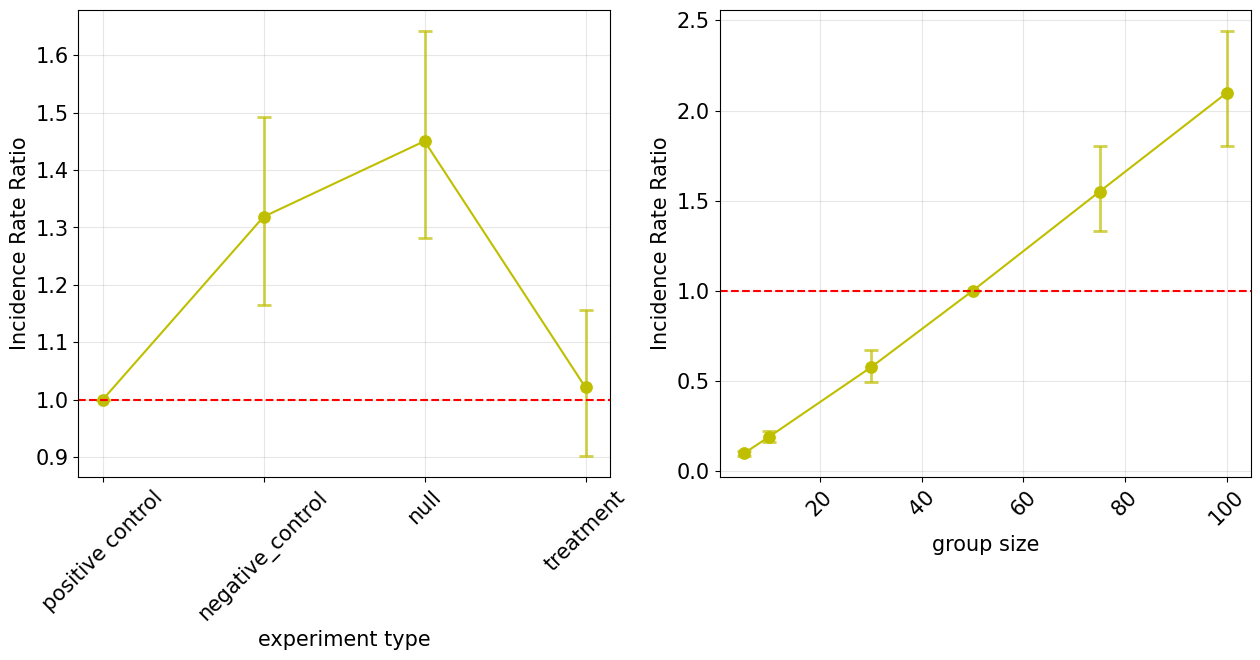

In [44]:
plt.figure(figsize=(25, 25))
for i, param in enumerate(varying_params):
    subset_df = condensed_nb_df.groupby("parameter").get_group(param).reset_index()
    
    y_vals= subset_df['odds_ratio']
    x_vals= subset_df['parameter_value']
    lower = subset_df['ci_low']
    upper = subset_df['ci_high']
    lower_error = y_vals - lower
    upper_error = upper - y_vals
    # x_vals = [str(i) for i in x_vals]
    errors = [lower_error, upper_error]
    plt.subplot(4,4,i+3)
    ax = sns.lineplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], ls='-', color="y")  # Black line with dots
    sns.scatterplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], s=100, color='y')
    
    plt.errorbar(x_vals, y_vals, yerr=errors,fmt='none',capsize=5,capthick=2, alpha=0.7,elinewidth=2, color="y"
    )
    plt.axhline(1, color='red', linestyle='--')
    plt.xlabel(labels[i])
    plt.ylabel('Incidence Rate Ratio')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.xticks(rotation=45)
    # plt.ylim(0.2,2.5)
# plt.suptitle("Space occupied, Odds ratios of Binomial fit")
# plt.show()
# print(errors)

plt.savefig("collisioncountsvsgroupsize_glm.svg", transparent= True)

In [29]:
varying_params = ["experiment_type", 'group_size']
labels = ['experiment type', 'group size']
df_cat = df.copy()

# df_cat["group_size"] = pd.Categorical(df_cat["group_size"])
df_cat["experiment_type"] = pd.Categorical(df_cat["experiment_type"])

formula = """
collision_counts ~ C(experiment_type, Treatment(reference="positive_control")) + group_size
"""

# First fit Poisson to estimate dispersion
poisson_model = smf.glm(formula=formula, data=df_cat, family=sm.families.Poisson()).fit()
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
print(dispersion)
alpha = 1/dispersion
print(alpha)

# Fit Negative Binomial with categorical variables
model_nb_2 = smf.glm(
    formula=formula,
    data=df_cat,
    family= NegativeBinomial(alpha=alpha),
    # contrasts=contrast_code
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)")
print(model_nb_2.summary2())
print(f"\nFinal alpha parameter: {model_nb_2.family.alpha:.4f}")

54.749179397446184
0.01826511394336343
NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)
                                               Results: Generalized linear model
Model:                                     GLM                                   AIC:                                 8303.7005
Link Function:                             Log                                   BIC:                                 250.9238 
Dependent Variable:                        collision_counts                      Log-Likelihood:                      -4146.9  
Date:                                      2026-05-13 16:39                      LL-Null:                             -13820.  
No. Observations:                          480                                   Deviance:                            3183.5   
Df Model:                                  4                                     Pearson chi2:                        2.86e+03 
Df Residuals:                              475     

['C(experiment_type, Treatment(reference="positive_control"))[T.negative_control]', 'C(experiment_type, Treatment(reference="positive_control"))[T.null]', 'C(experiment_type, Treatment(reference="positive_control"))[T.treatment]']


c:\Users\adity\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


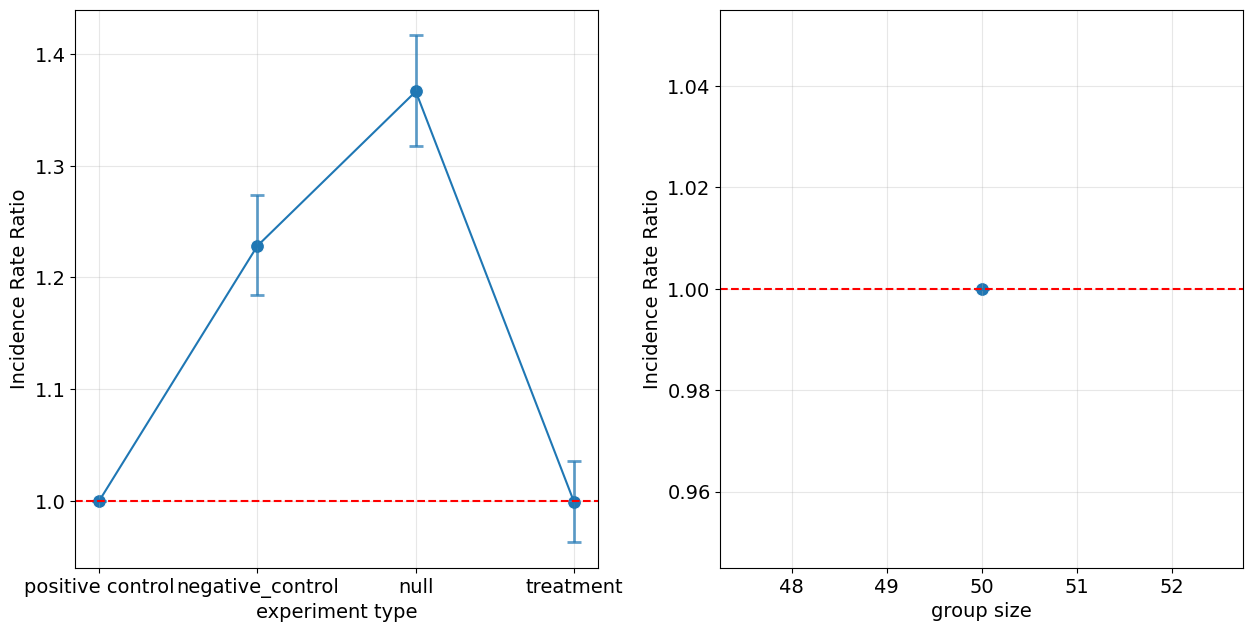

In [30]:
results = model_nb_2.summary2().tables[1]
categorical_params = [p for p in results.index if '[' in p]
print(categorical_params)
# Create a plot for each parameter
baseline_df = pd.DataFrame()
baseline_df["parameter"] = varying_params
baseline_df["odds_ratio"] = [1] * len(varying_params)
baseline_df["parameter_value"] = ['positive control', 50]
baseline_df["ci_low"] = [1] * len(varying_params)
baseline_df["ci_high"] = [1] * len(varying_params)
baseline_df["pvalue"] = [0] * len(varying_params)
baseline_df["coeffs"] = [0] * len(varying_params)

parameter_list = []
parameter_value_list = []
odds_ratio_list = []
ci_low_list = []
ci_high_list = []
pvalue_list = []
coeffs_list = []

for param in categorical_params:
    # Extract base parameter name and category
    base_param = param.split(',')[0].split(")")[0][2:]
    # base_param = param.split('[')[0]
    category = param.split('[')[1].split(']')[0].replace('T.', '')
    if category not in ["negative_control", "null", "treatment"]:
        category = float(category)
    # print(category)
    
    or_val = np.exp(results.loc[param, 'Coef.'])
    ci_low = np.exp(results.loc[param, '[0.025'])
    ci_high = np.exp(results.loc[param, '0.975]'])
    pvalue = results.loc[param, 'P>|z|']
    coeff= results.loc[param, 'Coef.']
    
    parameter_value_list.append(category)
    parameter_list.append(base_param)
    odds_ratio_list.append(or_val)
    ci_low_list.append(ci_low)
    ci_high_list.append(ci_high)
    pvalue_list.append(pvalue)
    coeffs_list.append(coeff)
    
new_df = pd.DataFrame()
new_df["parameter"] = parameter_list
new_df["odds_ratio"] = odds_ratio_list
new_df["parameter_value"] = parameter_value_list
new_df["ci_low"] = ci_low_list
new_df["ci_high"] = ci_high_list
new_df["pvalue"] = pvalue_list
new_df["coeffs"] = coeffs_list
condensed_nb_df = pd.concat((baseline_df,new_df)).reset_index()
condensed_nb_df.sort_values('parameter').to_csv("group_nb_irr.csv")
condensed_nb_df
plt.figure(figsize=(25, 25))
for i, param in enumerate(varying_params):
    subset_df = condensed_nb_df.groupby("parameter").get_group(param).reset_index()
    
    y_vals= subset_df['odds_ratio']
    x_vals= subset_df['parameter_value']
    lower = subset_df['ci_low']
    upper = subset_df['ci_high']
    lower_error = y_vals - lower
    upper_error = upper - y_vals
    
    errors = [lower_error, upper_error]
    plt.subplot(4,4,i+3)
    ax = sns.lineplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], ls='-')  # Black line with dots
    sns.scatterplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], s=100)
    
    plt.errorbar(x_vals, y_vals, yerr=errors,fmt='none',capsize=5,capthick=2, alpha=0.7,elinewidth=2
    )
    plt.axhline(1, color='red', linestyle='--')
    plt.xlabel(labels[i])
    plt.ylabel('Incidence Rate Ratio')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.ylim(0.2,2.5)
# plt.suptitle("Space occupied, Odds ratios of Binomial fit")
plt.show()
# print(errors)